<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>  

<center>
  <h2 style="color:#000000";>Séance 3 : Equations différentielles (3)</h2>
</center>
<center>
  <h2 style="color:#000000";>Méthodes de Crank-Nicolson et Heun</h2>
</center>
<center>
  <h2 style="color:#000000";>CORRECTION </h2>
</center>

In [1]:
# Import des packages python
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

In [2]:
def linear(u, param) :
    return - param.a * u

In [3]:
def quadra(u, param) :
    return - param.a * u**2

In [4]:
def EulerExplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u[i+1] = u[i] + dt * param.function(u[i], param) 
    param.solution_approchee = u

In [5]:
def fonct_implicite(u_np1, u_n):
    g_u = param.function(u_np1, param) - (u_np1 - u_n) / param.dt
    return g_u

In [6]:
def EulerImplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    u = np.zeros(n+1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_implicite, u[i], u[i])
    param.solution_approchee = u

In [7]:
def tabtemps(param) :
    param.t = np.linspace(0, param.T, param.n + 1)

In [8]:
def calcul_solution_exacte(param) :
    param.solution_exacte = np.zeros(param.n + 1)
    param.solution_exacte = param.exact(param)

In [9]:
def sol_ex_lin(param) :
    return np.exp(-param.a * param.t) * param.u0

In [10]:
def sol_ex_quad(param) :
    return param.u0 / (1 + param.u0 * param.a * param.t)

In [11]:
def OrdreConv(ite, err) :
    # calcul des logarithmes base 2 des tableaux ite et err
    ite = np.log(ite) / np.log(2)
    err = np.log(err) / np.log(2)
    
    # calcul du coefficient directeur alpha
    x2m = np.var(ite)
    alpha = np.cov(ite, err, bias=True)[0,1] / x2m
    
    return np.abs(alpha)

In [12]:
def calcul_ite_err(N, param) :
    '''
    Programme qui lance N simulations et qui créé les tableaux
    "ite" et "err" associés pour une étude de convergence numérique.
    Entrées :
        @ N : nombre de simulations à effectuer
        @ param : objet de la classe Param, contenant 
                  parmi ses attributs, les paramètres des simulations
    Sorties :
        @ite, err : les 2 tableaux numpy contenant le nombre de pas de temps (=ite)
                    et l'erreur pour chacune des N simulations.
    '''
    
    ite = np.zeros(N)
    err = np.zeros(N)
    for i in range (0, N): # boucle sur les N simulations
        ite[i] = 2**(i+2)
    
        param.n = int(ite[i])
        param.dt = param.T / param.n 

        tabtemps(param) # ==> mise à jour de param.t 
        calcul_solution_exacte(param) # ==> mise à jour des n + 1 valeurs de la solution exacte dans param.solution_exacte
        param.schema(param) # ==> mise à jour de param.solution_approchee avec le schema choisi
    
        # calcul de l'erreur pour le dernier itéré (t = n * dt), cad pour le dernier élément du tableau u et u_ex
        err[i] = np.abs(param.solution_approchee[param.n] - param.solution_exacte[param.n])
        
    return ite, err

In [13]:
def graphique(param) :
    fig, ax = plt.subplots(figsize=(7,4))
    ax.set_xlim(-0.01, param.T + 0.1)

    ax.plot(param.t, param.solution_exacte, color='red', label='solution exacte ')
    ax.plot(param.t, param.solution_approchee, color='black', marker='*', lw=0, label='solution approchee ')
    plt.xlabel('Temps')
    plt.ylabel('Solution u(t)')
    ax.grid(True)
    ax.legend(loc='best')

    plt.draw()

In [14]:
def PlotConv(ite, err) :
    # calcul des logarithmes base 2 des tableaux ite et err
    ite = np.log(ite) / np.log(2)
    err = np.log(err) / np.log(2)
    
    # tracé de la courbe de convergence
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title( 'convergence' ) 
    ax.set_xlabel('logarithme base 2 du nombre d iterations')
    ax.set_ylabel('logarithme base 2 de l erreur')
    ax.plot (ite,err,'r*')   
    plt.grid(True)
    plt.draw()
    
    return

In [15]:
class Param (object) : 
    ''' 
    Creation d'une classe Param dont la fonction principale (__init__) 
    spécifie tous les attributs des objets qui seront issus de cette classe Param.
    Ces attributs correspondent à l'ensemble des paramètres 
    à manipuler dans les simulations numériques.
    Les valeurs/instances données ici à ces paramètres sont des valeurs par défaut.
    '''
    def __init__ (self):
        # Paramètres de discrétisation temporelle
        self.u0 = 1.
        self.a = 1.
        self.T = 1.
        self.cfl = 0.
        self.dt = 0.
        self.n = 0
        self.t = np.zeros(self.n + 1)
        
        # Tableaux des solutions exacte et approchée        
        self.solution_exacte = np.zeros(self.n + 1)
        self.solution_approchee = np.zeros(self.n + 1)
        
        # Fonctions python par défaut pour les simulations        
        self.function = linear
        self.exact = sol_ex_lin
        self.schema = EulerExplicite

## Questions Partie A : Méthode de Crank-Nicolson

Le but de cette partie est d'implémenter la méthode de Crank-Nicolson.  

**1)** On a vu dans la partie cours que le calcul de l'itéré $u^{n+1}$ par la méthode de Crank-Nicolson reposait sur la résolution de l'équation $(3)$, qui est équivalente à :

$$\underbrace{2 \big ( \dfrac{u^{n}-u^{n+1}}{\Delta t} \big ) + f(u^{n+1}) + f(u^{n})}_{g(u^{n+1})} = 0$$

**2)** En vous inspirant des fonctions python implémentées lors des TP précédents (cf ci-dessus), implémenter une fonction python `fonct_cranknicolson` qui à partir des valeurs des itérés $u^{n+1}$ et $u^{n}$, renvoie la valeur $ \ g(u^{n+1}) = 2 \big ( \dfrac{u^{n}-u^{n+1}}{\Delta t} \big ) + f(u^{n+1}) + f(u^{n}) \ $.

In [16]:
def fonct_cranknicolson(u_np1, u_n): # garder les arguments dans cet ordre
    g_u = 2. * ((u_n - u_np1) / param.dt) + param.function(u_np1, param) + param.function(u_n, param)
    return g_u

**3)** Compléter la fonction python `CrankNicolson` ci-dessous. Vous pourrez vous inspirer de la fonction `EulerImplicite` implémentée lors des TP précédents (cf ci-dessus).

In [17]:
def CrankNicolson(param) : # schéma numérique de Crank-Nicolson
    u0 = param.u0
    dt = param.dt
    n = param.n
    u = np.zeros(n+1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_cranknicolson, u[i], u[i])
    param.solution_approchee = u

**4)** Tester votre fonction `CrankNicolson` avec :
* le cas quadratique $f(u) = -a \ u^2$, avec $a=1$ et $u_0 = 1$

Vous représenterez sur un même graphique la solution numérique obtenue ainsi que la solution exacte en appelant la fonction `graphique` redonnée ci-dessus.   

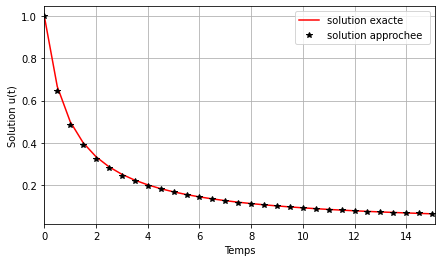

In [18]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.T = 15.
param.dt = 0.5
param.n = int(param.T / param.dt)
param.function = quadra
param.exact = sol_ex_quad

# Appel des fonctions python 
tabtemps(param)
calcul_solution_exacte(param)
CrankNicolson(param)

# Tracé du graphique
graphique(param)

**5)** Calculer l'ordre de convergence de la méthode de Crank-Nicolson par regression linéaire. Vous vous servirez pour cela de la fonction `OrdreConv` implémentée lors du TP précédent et donnée ci-dessus.

In [19]:
param.T = 1.
N = 10
param.schema = CrankNicolson

# calcul des tableaux "ite" et "err"
ite, err = calcul_ite_err(N, param)

# appel de OrdreConv
if (N >= 2) :
    ordre = OrdreConv(ite, err)
    print('ordre Crank-Nicolson =', ordre)

ordre Crank-Nicolson = 2.001786956367202


## Questions Partie B : Méthode de Heun

Le but de cette partie est d'implémenter la méthode de Heun. D'après le cours, on sait que le schéma de Heun s'écrit comme suit :

$$
\displaystyle   u^{n+1} =  \displaystyle{{ 1}\over{2 }}\big( \underbrace{u^n  + \Delta t \,f(u^n)}_{{\widetilde u_1}\,^{n+1}}\big) + \displaystyle{{ 1}\over{2 }}\big( \underbrace{u^n  +  \Delta t \,f( \ {\widetilde u_1}\,^{n+1})}_{{\widetilde u_2}\,^{n+1}}\big) 
$$

**6)** 
* Compléter la fonction Python `Heun` ci-dessous.    
* Tester votre fonction `Heun` dans le cas quadratique ($f(u) = -a \ u^2$, avec $a=1$ et $u_0 = 1$)  
* Représenter sur un même graphique la solution numérique obtenue ainsi que la solution exacte (appel de la fonction `graphique`).  
* Calculer l'ordre de convergence de la méthode de Heun par regression linéaire.

In [20]:
def Heun(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u_tilde1 = u[i] + dt * param.function(u[i], param) 
        u_tilde2 = u[i] + dt * param.function(u_tilde1, param)
        u[i+1] = 0.5 * u_tilde1 + 0.5 * u_tilde2
    param.solution_approchee = u

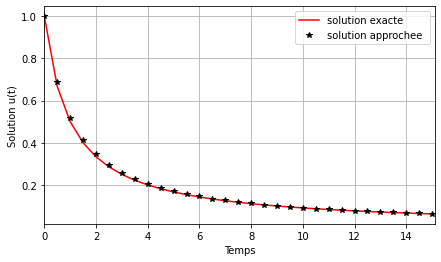

In [21]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.T = 15.
param.dt = 0.5
param.n = int(param.T / param.dt)
param.function = quadra
param.exact = sol_ex_quad

# Appel des fonctions python 
tabtemps(param)
calcul_solution_exacte(param)
Heun(param)

# Tracé du graphique
graphique(param)

In [22]:
param.T = 1.
N = 10
param.schema = Heun
# calcul des tableaux "ite" et "err"
ite, err = calcul_ite_err(N, param)

# appel de OrdreConv
if (N >= 2) :
    ordre = OrdreConv(ite, err)
    print('ordre Heun =', ordre)

ordre Heun = 2.020010633366172


## Questions Partie C : Bilan final des 4 méthodes (Euler explicite, Euler implicite, Crank-Nicolson, Heun)

Le but de cette partie est de comparer graphiquement les 4 méthodes.

**7)** Tracer sur un même graphique la solution exacte ainsi que **les solutions numériques** obtenues avec les 4 méthodes dans le cas **linéaire** ($f(u) = -a \ u$, avec $a=1$ et $u_0 = 1$).  
Vous vous servirez pour cela de la fonction `graphique4c` déjà implémentée et donnée ci-dessous.

In [23]:
def graphique4c(u_Eul_ex, u_Eul_imp, u_Crank, u_Heun, param) :
    
    '''
    Fonction permettant de tracer sur un même graphique 
    la solution exacte et les solutions issues des 4 methodes numeriques.
        @ u_Eul_ex : tableau numpy de la solution u pour le schéma d'Euler explicite
        @ u_Eul_imp : tableau numpy de la solution u pour le schéma d'Euler implicite
        @ u_Crank : tableau numpy de la solution u pour le schéma de Crank Nicolson
        @ u_Heun : tableau numpy de la solution u pour le schéma de Heun
    '''
    
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_xlim(-.01, param.T+0.1)

    ax.plot (param.t, param.solution_exacte, 'r--', label='solution exacte ')
    ax.plot (param.t, u_Eul_ex, color='blue', marker='*' , lw=0, label='Euler Explicite ')
    ax.plot (param.t, u_Eul_imp, color='orange', marker='*' , lw=0, label='Euler Implicite ')
    ax.plot (param.t, u_Crank, color='green', marker='*' , lw=0, label='Crank Nicolson ')
    ax.plot (param.t, u_Heun, color='purple', marker='*' , lw=0, label='Heun ')

    plt.xlabel('Time')
    plt.ylabel('Solution u(t)')
    ax.legend(loc='best')
    plt.grid(True)

    plt.draw()

In [24]:
# On définit des paramètres de simulation qui seront communs aux 4 schémas.
# Notamment, on choisit un dt (et donc une CFL) qui soit compatible avec
# la condition de stabilité du schéma d'Euler explicite
param = Param()
param.T = 6.
param.cfl = 0.2
param.dt = 2. * param.cfl / param.a
param.n = int(param.T / param.dt)
print("nombre pas de temps : ", param.n)

tabtemps(param)
calcul_solution_exacte(param) # par défaut, la solution exacte est calculée à partir de la fonction f linéaire

# Calcul des 4 solutions approchées
EulerExplicite(param)
uee = param.solution_approchee
EulerImplicite(param)
uei = param.solution_approchee
CrankNicolson(param)
ucn = param.solution_approchee
Heun(param)
uh = param.solution_approchee

nombre pas de temps :  15


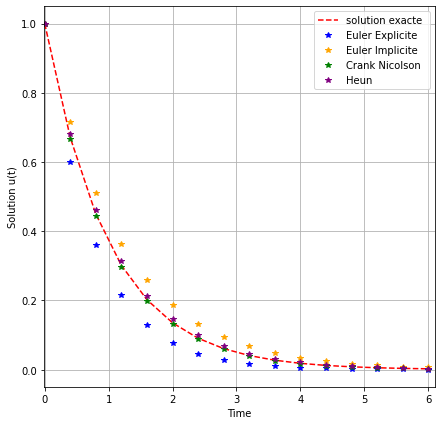

In [25]:
# Appel de la fonction graphique4c :
graphique4c(uee, uei, ucn, uh, param)

**8)** Tracer sur un même graphique **les courbes de convergence** des 4 méthodes (toujours dans le cas **linéaire** $f(u) = -a \ u$, avec $a=1$ et $u_0 = 1$).  
Vous vous servirez pour cela de la fonction `PlotConv4c` déjà implémentée et donnée ci-dessous.

In [26]:
def PlotConv4c(ite, errEE, errEI, errCN, errH) :

    '''
    Fonction permettant de tracer sur le même graphique 
    les courbes de convergence des 4 methodes numeriques.
        @ ite : tableau numpy des nombres d'iterations de chaque simulation
        @ errEE : tableau numpy des erreurs pour le schéma d'Euler explicite
        @ errEI : tableau numpy des erreurs pour le schéma d'Euler implicite
        @ errCN : tableau numpy des erreurs pour le schéma de Crank Nicolson
        @ errH : tableau numpy des erreurs pour le schéma de Heun
    '''
    
    # calcul des logarithmes base 2 des tableaux
    ite = np.log(ite) / np.log(2)
    errEE = np.log(errEE) / np.log(2)
    errEI = np.log(errEI) / np.log(2)
    errCN = np.log(errCN) / np.log(2)
    errH = np.log(errH) / np.log(2)
    
    # tracé des 4 courbes de convergence
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title( 'convergence' ) 
    ax.set_xlabel('logarithme base 2 du nombre de pas de temps')
    ax.set_ylabel('logarithme base 2 de l erreur')
    ax.plot (ite, errEE, color='blue',marker='*',label='Euler Explicite ')   
    ax.plot (ite, errEI, color='orange',marker='*',label='Euler Implicite ')   
    ax.plot (ite, errCN, color='green',marker='*',label='Crank Nicolson ')   
    ax.plot (ite, errH, color='purple',marker='*',label='Heun ')   
    ax.legend(loc='best')
    plt.grid(True)
    plt.draw()
    
    return

In [27]:
param = Param()
N = 8
errEE = np.zeros(N)
errEI = np.zeros(N)
errCN = np.zeros(N)
errH = np.zeros(N)
ite = np.zeros(N)
for i in range (0,N) :
    ite[i] = 2**(i+2)
    
    param.n = int(ite[i])
    n = param.n
    param.dt = param.T / param.n 
    
    tabtemps(param)
    calcul_solution_exacte(param)
    
    # Calcul des 4 erreurs
    EulerExplicite(param)
    errEE[i] = np.abs(param.solution_approchee[n]-param.solution_exacte[n])
    #
    EulerImplicite(param)
    errEI[i] = np.abs(param.solution_approchee[n]-param.solution_exacte[n])
    #
    CrankNicolson(param)
    errCN[i] = np.abs(param.solution_approchee[n]-param.solution_exacte[n])
    #
    Heun(param)
    errH[i] = np.abs(param.solution_approchee[n]-param.solution_exacte[n])

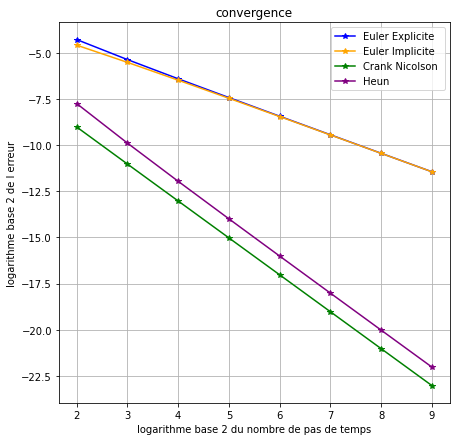

In [28]:
# Appel de la fonction PlotConv4c pour le tracé des 4 courbes de convergence
if (N >= 2) :
    PlotConv4c(ite, errEE, errEI, errCN, errH)